In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation/Class_12_duck_weeds/image_839.jpg
/kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation/Class_12_duck_weeds/image_846.jpg
/kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation/Class_12_duck_weeds/image_894.jpg
/kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation/Class_12_duck_weeds/image_834.jpg
/kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation/Class_12_duck_weeds/image_865.jpg
/kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation/Class_12_duck_weeds/image_887.jpg
/kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation/Class_12_duck_weeds/image_870.jpg
/kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation/Class_12_duck_weeds/image_880.jpg
/kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation/Class_12_duck_weeds/image_

In [28]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is NOT enabled!")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [29]:
import os

print("Available Kaggle datasets:\n")

for item in os.listdir("/kaggle/input"):
    print(item)

Available Kaggle datasets:

datasets


In [30]:
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)

    if level <= 3:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        for f in files[:3]:
            print(f"{indent}    {f}")

input/
    datasets/
        soishabsarkar/
            aquplantsres/


In [31]:
import os

INPUT_ROOT = "/kaggle/input"

def find_dataset_root(input_root):
    for root, dirs, files in os.walk(input_root):

        dir_names = {d.lower(): d for d in dirs}

        has_train = "train" in dir_names
        has_val = (
            "validation" in dir_names or
            "val" in dir_names or
            "valid" in dir_names
        )
        has_test = "test" in dir_names

        if has_train and has_val and has_test:

            train_name = dir_names["train"]

            if "validation" in dir_names:
                val_name = dir_names["validation"]
            elif "valid" in dir_names:
                val_name = dir_names["valid"]
            else:
                val_name = dir_names["val"]

            test_name = dir_names["test"]

            return (
                root,
                os.path.join(root, train_name),
                os.path.join(root, val_name),
                os.path.join(root, test_name)
            )

    return None


paths = find_dataset_root(INPUT_ROOT)

if paths is None:
    raise RuntimeError(
        "Could not automatically find Train/Validation/Test folders."
    )

DATASET_ROOT, TRAIN_DIR, VAL_DIR, TEST_DIR = paths

print("Dataset root :", DATASET_ROOT)
print("Train path   :", TRAIN_DIR)
print("Validation   :", VAL_DIR)
print("Test path    :", TEST_DIR)

Dataset root : /kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL
Train path   : /kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Train
Validation   : /kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Validation
Test path    : /kaggle/input/datasets/soishabsarkar/aquplantsres/AquPlantDS_FINAL/Test


In [32]:
import os
from PIL import Image
from collections import Counter, defaultdict

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
)


def get_classes(folder):
    return sorted([
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d))
    ])


train_classes = get_classes(TRAIN_DIR)
val_classes   = get_classes(VAL_DIR)
test_classes  = get_classes(TEST_DIR)


print("=" * 70)
print("DATASET STRUCTURE CHECK")
print("=" * 70)

print("Train classes      :", len(train_classes))
print("Validation classes :", len(val_classes))
print("Test classes       :", len(test_classes))

print("\nTrain class names:")
for i, cls in enumerate(train_classes):
    print(f"{i:2d} -> {cls}")


same_classes = (
    train_classes == val_classes == test_classes
)

print("\nSame classes in all splits:", same_classes)

if not same_classes:
    print("\nTrain only:", set(train_classes) - set(val_classes))
    print("Validation only:", set(val_classes) - set(train_classes))
    print("Test only:", set(test_classes) - set(train_classes))

DATASET STRUCTURE CHECK
Train classes      : 14
Validation classes : 14
Test classes       : 14

Train class names:
 0 -> Class_10_lippia_alba
 1 -> Class_11_marsilea_minuta
 2 -> Class_12_duck_weeds
 3 -> Class_13_topapana
 4 -> Class_14_kachuripana
 5 -> Class_1_water_iris
 6 -> Class_2_pistia_stratiotes
 7 -> Class_3_lily_leaf
 8 -> Class_4_lotus-leaf
 9 -> Class_5_water_popy
10 -> Class_6_salvania
11 -> Class_7_chinese_water_spinach
12 -> Class_8_water_plantain
13 -> Class_9_mexican_sword_lily

Same classes in all splits: True


In [33]:
def audit_split(split_dir):

    counts = {}
    corrupt = []
    modes = Counter()
    resolutions = Counter()
    non_image_files = []

    for cls in sorted(os.listdir(split_dir)):

        cls_path = os.path.join(split_dir, cls)

        if not os.path.isdir(cls_path):
            continue

        count = 0

        for file in os.listdir(cls_path):

            file_path = os.path.join(cls_path, file)

            if not file.lower().endswith(IMAGE_EXTENSIONS):
                non_image_files.append(file_path)
                continue

            try:
                with Image.open(file_path) as img:

                    img.verify()

                with Image.open(file_path) as img:

                    modes[img.mode] += 1
                    resolutions[img.size] += 1

                count += 1

            except Exception as e:
                corrupt.append((file_path, str(e)))

        counts[cls] = count

    return counts, corrupt, modes, resolutions, non_image_files


train_info = audit_split(TRAIN_DIR)
val_info   = audit_split(VAL_DIR)
test_info  = audit_split(TEST_DIR)

In [34]:
splits = {
    "TRAIN": train_info,
    "VALIDATION": val_info,
    "TEST": test_info
}


for split_name, info in splits.items():

    counts, corrupt, modes, resolutions, non_images = info

    print("\n" + "=" * 70)
    print(split_name)
    print("=" * 70)

    total = sum(counts.values())

    print(f"Total images: {total}")

    print("\nImages per class:")

    for cls, n in counts.items():
        print(f"{cls:35s}: {n}")

    print("\nCorrupted images :", len(corrupt))
    print("Image modes      :", dict(modes))
    print("Unique resolutions:", len(resolutions))

    print("\nMost common resolutions:")

    for size, n in resolutions.most_common(10):
        print(size, ":", n)

    print("\nNon-image files:", len(non_images))


TRAIN
Total images: 744

Images per class:
Class_10_lippia_alba               : 50
Class_11_marsilea_minuta           : 55
Class_12_duck_weeds                : 50
Class_13_topapana                  : 61
Class_14_kachuripana               : 50
Class_1_water_iris                 : 50
Class_2_pistia_stratiotes          : 46
Class_3_lily_leaf                  : 65
Class_4_lotus-leaf                 : 57
Class_5_water_popy                 : 54
Class_6_salvania                   : 52
Class_7_chinese_water_spinach      : 47
Class_8_water_plantain             : 52
Class_9_mexican_sword_lily         : 55

Corrupted images : 0
Image modes      : {'RGB': 744}
Unique resolutions: 241

Most common resolutions:
(1920, 1080) : 243
(2016, 1512) : 86
(4032, 3024) : 42
(960, 540) : 11
(2637, 1978) : 10
(1602, 1201) : 9
(4000, 2250) : 6
(1252, 939) : 6
(1588, 1191) : 6
(1251, 938) : 6

Non-image files: 0

VALIDATION
Total images: 161

Images per class:
Class_10_lippia_alba               : 11
Class_11_ma

In [35]:
train_count = sum(train_info[0].values())
val_count   = sum(val_info[0].values())
test_count  = sum(test_info[0].values())

total_count = train_count + val_count + test_count

print("=" * 60)
print("EXPECTED vs FOUND")
print("=" * 60)

print(f"Train      : {train_count} / expected 744")
print(f"Validation : {val_count} / expected 161")
print(f"Test       : {test_count} / expected 157")
print(f"Total      : {total_count} / expected 1062")
print(f"Classes    : {len(train_classes)} / expected 14")


all_correct = (
    train_count == 744
    and val_count == 161
    and test_count == 157
    and total_count == 1062
    and len(train_classes) == 14
    and train_classes == val_classes == test_classes
    and len(train_info[1]) == 0
    and len(val_info[1]) == 0
    and len(test_info[1]) == 0
)


print("\n" + "=" * 60)

if all_correct:
    print("✅ DATASET READY FOR RESNET50 TRAINING")
else:
    print("⚠️ DATASET CHECK REQUIRES ATTENTION")

print("=" * 60)

EXPECTED vs FOUND
Train      : 744 / expected 744
Validation : 161 / expected 161
Test       : 157 / expected 157
Total      : 1062 / expected 1062
Classes    : 14 / expected 14

✅ DATASET READY FOR RESNET50 TRAINING


In [36]:
import hashlib


def file_hash(path):
    sha = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(8192)

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


def collect_hashes(folder):

    hashes = {}

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.lower().endswith(IMAGE_EXTENSIONS):

                path = os.path.join(root, file)
                h = file_hash(path)

                hashes[h] = path

    return hashes


train_hashes = collect_hashes(TRAIN_DIR)
val_hashes   = collect_hashes(VAL_DIR)
test_hashes  = collect_hashes(TEST_DIR)


train_val_overlap = set(train_hashes) & set(val_hashes)
train_test_overlap = set(train_hashes) & set(test_hashes)
val_test_overlap = set(val_hashes) & set(test_hashes)


print("Exact Train ↔ Validation duplicates:",
      len(train_val_overlap))

print("Exact Train ↔ Test duplicates:",
      len(train_test_overlap))

print("Exact Validation ↔ Test duplicates:",
      len(val_test_overlap))


if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
):
    print("\n✅ NO EXACT CROSS-SPLIT LEAKAGE")
else:
    print("\n❌ CROSS-SPLIT DUPLICATES DETECTED")

Exact Train ↔ Validation duplicates: 0
Exact Train ↔ Test duplicates: 0
Exact Validation ↔ Test duplicates: 0

✅ NO EXACT CROSS-SPLIT LEAKAGE


**Imports and reproducibility

Now we start the actual ResNet50 pipeline.**

In [37]:
import os
import random
import copy
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 14


print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [38]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])


val_test_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

In [39]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)


print("Train      :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test       :", len(test_dataset))

print("\nClasses:", len(train_dataset.classes))

for idx, class_name in enumerate(train_dataset.classes):
    print(idx, "->", class_name)

Train      : 744
Validation : 161
Test       : 157

Classes: 14
0 -> Class_10_lippia_alba
1 -> Class_11_marsilea_minuta
2 -> Class_12_duck_weeds
3 -> Class_13_topapana
4 -> Class_14_kachuripana
5 -> Class_1_water_iris
6 -> Class_2_pistia_stratiotes
7 -> Class_3_lily_leaf
8 -> Class_4_lotus-leaf
9 -> Class_5_water_popy
10 -> Class_6_salvania
11 -> Class_7_chinese_water_spinach
12 -> Class_8_water_plantain
13 -> Class_9_mexican_sword_lily


In [40]:
assert train_dataset.class_to_idx == val_dataset.class_to_idx, \
    "Train/Validation class mapping mismatch"

assert train_dataset.class_to_idx == test_dataset.class_to_idx, \
    "Train/Test class mapping mismatch"


print("✅ Class mappings are identical.")
print()

print(train_dataset.class_to_idx)

✅ Class mappings are identical.

{'Class_10_lippia_alba': 0, 'Class_11_marsilea_minuta': 1, 'Class_12_duck_weeds': 2, 'Class_13_topapana': 3, 'Class_14_kachuripana': 4, 'Class_1_water_iris': 5, 'Class_2_pistia_stratiotes': 6, 'Class_3_lily_leaf': 7, 'Class_4_lotus-leaf': 8, 'Class_5_water_popy': 9, 'Class_6_salvania': 10, 'Class_7_chinese_water_spinach': 11, 'Class_8_water_plantain': 12, 'Class_9_mexican_sword_lily': 13}


In [41]:
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


print("Train batches      :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches       :", len(test_loader))

Train batches      : 24
Validation batches : 6
Test batches       : 5


In [42]:
images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

print("\nImage dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("\nExample labels:")
print(labels[:10])

Image batch shape : torch.Size([32, 3, 224, 224])
Label batch shape : torch.Size([32])

Image dtype: torch.float32
Label dtype: torch.int64

Example labels:
tensor([ 7, 12, 12,  0,  8,  1, 10,  5,  7,  7])


In [43]:
assert len(train_dataset) == 744
assert len(val_dataset) == 161
assert len(test_dataset) == 157

assert len(train_dataset.classes) == 14

assert images.shape[1] == 3
assert images.shape[2] == 224
assert images.shape[3] == 224

assert train_dataset.class_to_idx == val_dataset.class_to_idx
assert train_dataset.class_to_idx == test_dataset.class_to_idx


print("=" * 65)
print("RESNET50 INPUT PIPELINE")
print("=" * 65)

print("Train       :", len(train_dataset))
print("Validation  :", len(val_dataset))
print("Test        :", len(test_dataset))
print("Classes     :", len(train_dataset.classes))
print("Input shape :", images.shape)
print("Device      :", DEVICE)

print("\n✅ PREPROCESSING DATASET IS READY")
print("✅ READY TO LOAD IMAGENET-PRETRAINED RESNET50")

RESNET50 INPUT PIPELINE
Train       : 744
Validation  : 161
Test        : 157
Classes     : 14
Input shape : torch.Size([32, 3, 224, 224])
Device      : cuda

✅ PREPROCESSING DATASET IS READY
✅ READY TO LOAD IMAGENET-PRETRAINED RESNET50


In [44]:
from torchvision.models import resnet50, ResNet50_Weights


weights = ResNet50_Weights.DEFAULT

model = resnet50(
    weights=weights
)

print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [45]:
num_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Dropout(p=0.3),

    nn.Linear(
        num_features,
        NUM_CLASSES
    )
)

model = model.to(DEVICE)

print(model.fc)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=14, bias=True)
)


In [46]:
for param in model.parameters():
    param.requires_grad = False


# Only new classifier remains trainable
for param in model.fc.parameters():
    param.requires_grad = True

In [47]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 23,536,718
Trainable parameters : 28,686


In [48]:
criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [49]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4


optimizer = optim.AdamW(
    model.fc.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


print("Optimizer:", optimizer.__class__.__name__)
print("Scheduler:", scheduler.__class__.__name__)

Optimizer: AdamW
Scheduler: ReduceLROnPlateau


In [50]:
def run_epoch(
    model,
    loader,
    criterion,
    device,
    optimizer=None
):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        if is_training:
            optimizer.zero_grad()


        with torch.set_grad_enabled(is_training):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


            if is_training:

                loss.backward()

                optimizer.step()


        running_loss += (
            loss.item() *
            images.size(0)
        )


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )


    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )


    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )


    precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )


    recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )


    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )


    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "macro_f1": macro_f1
    }

In [51]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=25,
    patience=7,
    save_path="/kaggle/working/resnet50_stage1_best.pth"
):

    history = []

    best_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0

    best_weights = copy.deepcopy(
        model.state_dict()
    )


    for epoch in range(1, epochs + 1):

        start_time = time.time()


        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            device,
            optimizer
        )


        val_metrics = run_epoch(
            model,
            val_loader,
            criterion,
            device
        )


        current_lr = optimizer.param_groups[0]["lr"]


        scheduler.step(
            val_metrics["macro_f1"]
        )


        history.append({

            "epoch": epoch,

            "train_loss":
                train_metrics["loss"],

            "train_accuracy":
                train_metrics["accuracy"],

            "train_macro_f1":
                train_metrics["macro_f1"],

            "val_loss":
                val_metrics["loss"],

            "val_accuracy":
                val_metrics["accuracy"],

            "val_precision":
                val_metrics["precision"],

            "val_recall":
                val_metrics["recall"],

            "val_macro_f1":
                val_metrics["macro_f1"],

            "learning_rate":
                current_lr

        })


        elapsed = (
            time.time() -
            start_time
        )


        print(
            f"\nEpoch {epoch:02d}/{epochs}"
        )

        print(
            f"Train | "
            f"Loss: {train_metrics['loss']:.4f} | "
            f"Acc: {train_metrics['accuracy']*100:.2f}% | "
            f"Macro-F1: {train_metrics['macro_f1']*100:.2f}%"
        )

        print(
            f"Val   | "
            f"Loss: {val_metrics['loss']:.4f} | "
            f"Acc: {val_metrics['accuracy']*100:.2f}% | "
            f"Precision: {val_metrics['precision']*100:.2f}% | "
            f"Recall: {val_metrics['recall']*100:.2f}% | "
            f"Macro-F1: {val_metrics['macro_f1']*100:.2f}%"
        )

        print(
            f"LR: {current_lr:.2e} | "
            f"Time: {elapsed:.1f}s"
        )


        if val_metrics["macro_f1"] > best_f1:

            best_f1 = (
                val_metrics["macro_f1"]
            )

            best_epoch = epoch

            best_weights = copy.deepcopy(
                model.state_dict()
            )


            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict":
                        best_weights,
                    "optimizer_state_dict":
                        optimizer.state_dict(),
                    "val_macro_f1":
                        best_f1,
                    "class_to_idx":
                        train_dataset.class_to_idx
                },
                save_path
            )


            epochs_without_improvement = 0


            print(
                "✅ New best model saved"
            )


        else:

            epochs_without_improvement += 1


            print(
                "No improvement:",
                epochs_without_improvement,
                "/",
                patience
            )


        if epochs_without_improvement >= patience:

            print(
                "\nEarly stopping triggered."
            )

            break


    model.load_state_dict(
        best_weights
    )


    print("\n" + "=" * 65)
    print("TRAINING COMPLETE")
    print("=" * 65)

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        f"Best validation Macro-F1: "
        f"{best_f1*100:.2f}%"
    )


    return (
        model,
        pd.DataFrame(history)
    )

In [52]:
STAGE1_EPOCHS = 100


model, history_stage1 = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    device=DEVICE,

    epochs=STAGE1_EPOCHS,

    patience=10,

    save_path=
    "/kaggle/working/resnet50_stage1_best.pth"
)


Epoch 01/100
Train | Loss: 2.2711 | Acc: 34.81% | Macro-F1: 33.89%
Val   | Loss: 1.8447 | Acc: 77.64% | Precision: 85.80% | Recall: 78.10% | Macro-F1: 77.70%
LR: 1.00e-03 | Time: 19.6s
✅ New best model saved

Epoch 02/100
Train | Loss: 1.4930 | Acc: 80.24% | Macro-F1: 79.81%
Val   | Loss: 1.2656 | Acc: 89.44% | Precision: 90.29% | Recall: 89.92% | Macro-F1: 89.71%
LR: 1.00e-03 | Time: 18.7s
✅ New best model saved

Epoch 03/100
Train | Loss: 1.0791 | Acc: 88.71% | Macro-F1: 88.78%
Val   | Loss: 0.9534 | Acc: 90.06% | Precision: 91.14% | Recall: 90.57% | Macro-F1: 90.27%
LR: 1.00e-03 | Time: 19.1s
✅ New best model saved

Epoch 04/100
Train | Loss: 0.8278 | Acc: 90.19% | Macro-F1: 90.32%
Val   | Loss: 0.7589 | Acc: 91.93% | Precision: 92.55% | Recall: 92.27% | Macro-F1: 91.99%
LR: 1.00e-03 | Time: 19.3s
✅ New best model saved

Epoch 05/100
Train | Loss: 0.6834 | Acc: 91.94% | Macro-F1: 92.10%
Val   | Loss: 0.6242 | Acc: 95.03% | Precision: 95.42% | Recall: 94.99% | Macro-F1: 95.05%
LR: 1

In [53]:
history_stage1.tail()

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_precision,val_recall,val_macro_f1,learning_rate
32,33,0.123550,0.991935,0.992112,0.168975,0.975155,0.975025,0.974567,0.974248,0.000125
33,34,0.152137,0.981183,0.981136,0.158376,0.975155,0.976024,0.974567,0.974483,0.000125
34,35,0.128582,0.995968,0.995623,0.165480,0.981366,0.982060,0.981061,0.981037,0.000125
35,36,0.122665,0.990591,0.990170,0.156322,0.981366,0.982517,0.981061,0.981285,0.000063
36,37,0.131085,0.983871,0.984311,0.164140,0.975155,0.975025,0.974567,0.974248,0.000063


In [54]:
best_row = history_stage1.loc[
    history_stage1["val_macro_f1"].idxmax()
]

print("=" * 60)
print("RESNET50 FROZEN BACKBONE BEST RESULT")
print("=" * 60)

print(
    f"Best Epoch        : "
    f"{int(best_row['epoch'])}"
)

print(
    f"Validation Acc    : "
    f"{best_row['val_accuracy']*100:.2f}%"
)

print(
    f"Validation Precision: "
    f"{best_row['val_precision']*100:.2f}%"
)

print(
    f"Validation Recall : "
    f"{best_row['val_recall']*100:.2f}%"
)

print(
    f"Validation Macro-F1: "
    f"{best_row['val_macro_f1']*100:.2f}%"
)

print(
    f"Validation Loss   : "
    f"{best_row['val_loss']:.4f}"
)

RESNET50 FROZEN BACKBONE BEST RESULT
Best Epoch        : 27
Validation Acc    : 98.14%
Validation Precision: 98.25%
Validation Recall : 98.11%
Validation Macro-F1: 98.13%
Validation Loss   : 0.1712


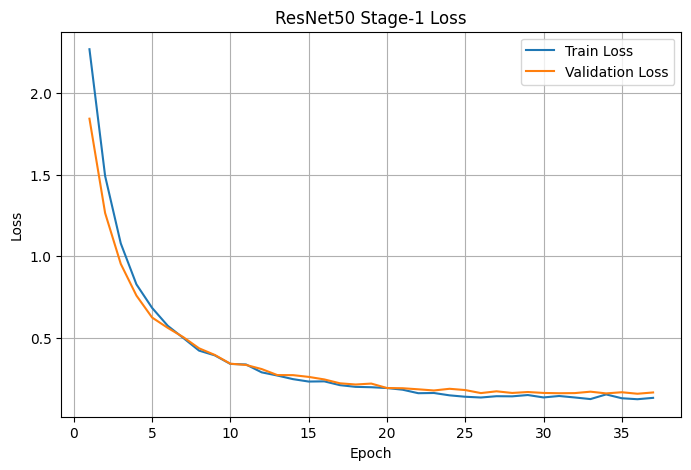

In [55]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(
    history_stage1["epoch"],
    history_stage1["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_stage1["epoch"],
    history_stage1["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Stage-1 Loss")
plt.legend()
plt.grid()

plt.show()

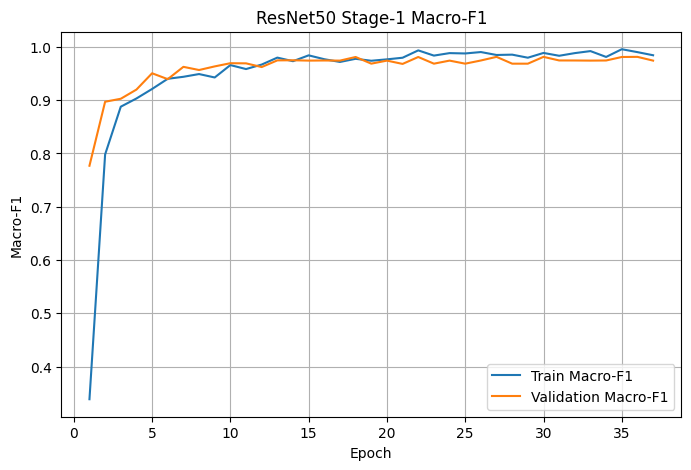

In [56]:
plt.figure(figsize=(8,5))

plt.plot(
    history_stage1["epoch"],
    history_stage1["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    history_stage1["epoch"],
    history_stage1["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("ResNet50 Stage-1 Macro-F1")
plt.legend()
plt.grid()

plt.show()

> *Stage 2: Fine-tune ResNet50***

In [57]:
checkpoint = torch.load(
    "/kaggle/working/resnet50_stage1_best.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Loaded Stage-1 checkpoint from epoch:",
    checkpoint["epoch"]
)

print(
    f"Stage-1 best Macro-F1: "
    f"{checkpoint['val_macro_f1']*100:.2f}%"
)

Loaded Stage-1 checkpoint from epoch: 27
Stage-1 best Macro-F1: 98.13%


In [58]:
for param in model.parameters():
    param.requires_grad = False


# Unfreeze last ResNet block
for param in model.layer4.parameters():
    param.requires_grad = True


# Keep classifier trainable
for param in model.fc.parameters():
    param.requires_grad = True

In [59]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)


print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

print(
    f"Trainable percentage: "
    f"{100*trainable_params/total_params:.2f}%"
)

Total parameters: 23,536,718
Trainable parameters: 14,993,422
Trainable percentage: 63.70%


In [60]:
optimizer_ft = optim.AdamW(

    [
        {
            "params":
                model.layer4.parameters(),

            "lr": 1e-5
        },

        {
            "params":
                model.fc.parameters(),

            "lr": 1e-4
        }
    ],

    weight_decay=1e-4
)


scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer_ft,

    mode="max",

    factor=0.5,

    patience=3
)

In [61]:
model, history_stage2 = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer_ft,

    scheduler=scheduler_ft,

    device=DEVICE,

    epochs=100,

    patience=10,

    save_path=
    "/kaggle/working/resnet50_finetuned_best.pth"
)


Epoch 01/25
Train | Loss: 0.1313 | Acc: 98.52% | Macro-F1: 98.51%
Val   | Loss: 0.1422 | Acc: 98.14% | Precision: 98.25% | Recall: 98.11% | Macro-F1: 98.13%
LR: 1.00e-05 | Time: 19.2s
✅ New best model saved

Epoch 02/25
Train | Loss: 0.1133 | Acc: 98.52% | Macro-F1: 98.51%
Val   | Loss: 0.1487 | Acc: 96.89% | Precision: 96.96% | Recall: 96.95% | Macro-F1: 96.88%
LR: 1.00e-05 | Time: 20.0s
No improvement: 1 / 7

Epoch 03/25
Train | Loss: 0.1018 | Acc: 98.79% | Macro-F1: 98.81%
Val   | Loss: 0.1312 | Acc: 96.89% | Precision: 96.95% | Recall: 96.95% | Macro-F1: 96.87%
LR: 1.00e-05 | Time: 20.1s
No improvement: 2 / 7

Epoch 04/25
Train | Loss: 0.1013 | Acc: 98.12% | Macro-F1: 98.09%
Val   | Loss: 0.1250 | Acc: 96.89% | Precision: 96.95% | Recall: 96.95% | Macro-F1: 96.87%
LR: 1.00e-05 | Time: 19.6s
No improvement: 3 / 7

Epoch 05/25
Train | Loss: 0.0903 | Acc: 99.06% | Macro-F1: 99.05%
Val   | Loss: 0.1143 | Acc: 96.89% | Precision: 96.85% | Recall: 96.95% | Macro-F1: 96.85%
LR: 1.00e-05 

In [62]:
best_row_ft = history_stage2.loc[
    history_stage2[
        "val_macro_f1"
    ].idxmax()
]


print("=" * 65)
print("RESNET50 FINE-TUNED BEST VALIDATION RESULT")
print("=" * 65)

print(
    f"Best Epoch: "
    f"{int(best_row_ft['epoch'])}"
)

print(
    f"Validation Accuracy: "
    f"{best_row_ft['val_accuracy']*100:.2f}%"
)

print(
    f"Validation Precision: "
    f"{best_row_ft['val_precision']*100:.2f}%"
)

print(
    f"Validation Recall: "
    f"{best_row_ft['val_recall']*100:.2f}%"
)

print(
    f"Validation Macro-F1: "
    f"{best_row_ft['val_macro_f1']*100:.2f}%"
)

print(
    f"Validation Loss: "
    f"{best_row_ft['val_loss']:.4f}"
)

RESNET50 FINE-TUNED BEST VALIDATION RESULT
Best Epoch: 1
Validation Accuracy: 98.14%
Validation Precision: 98.25%
Validation Recall: 98.11%
Validation Macro-F1: 98.13%
Validation Loss: 0.1422


In [63]:
import os
import zipfile
import matplotlib.pyplot as plt

# ============================================================
# SAVE HISTORIES
# ============================================================

stage1_csv = "/kaggle/working/resnet50_stage1_history.csv"
stage2_csv = "/kaggle/working/resnet50_finetuned_history.csv"

history_stage1.to_csv(stage1_csv, index=False)
history_stage2.to_csv(stage2_csv, index=False)


# ============================================================
# SAVE STAGE-1 PLOTS
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_stage1["epoch"], history_stage1["train_loss"],
         label="Train Loss")
plt.plot(history_stage1["epoch"], history_stage1["val_loss"],
         label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Stage-1 Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/kaggle/working/resnet50_stage1_loss.png",
    dpi=300
)
plt.close()


plt.figure(figsize=(8, 5))
plt.plot(history_stage1["epoch"], history_stage1["train_macro_f1"],
         label="Train Macro-F1")
plt.plot(history_stage1["epoch"], history_stage1["val_macro_f1"],
         label="Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("ResNet50 Stage-1 Macro-F1")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/kaggle/working/resnet50_stage1_macro_f1.png",
    dpi=300
)
plt.close()


# ============================================================
# SAVE FINE-TUNING PLOTS
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_stage2["epoch"], history_stage2["train_loss"],
         label="Train Loss")
plt.plot(history_stage2["epoch"], history_stage2["val_loss"],
         label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Fine-Tuning Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/kaggle/working/resnet50_finetuned_loss.png",
    dpi=300
)
plt.close()


plt.figure(figsize=(8, 5))
plt.plot(history_stage2["epoch"], history_stage2["train_macro_f1"],
         label="Train Macro-F1")
plt.plot(history_stage2["epoch"], history_stage2["val_macro_f1"],
         label="Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("ResNet50 Fine-Tuning Macro-F1")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/kaggle/working/resnet50_finetuned_macro_f1.png",
    dpi=300
)
plt.close()


# ============================================================
# CHECK CRITICAL CHECKPOINTS
# ============================================================

stage1_pth = "/kaggle/working/resnet50_stage1_best.pth"
stage2_pth = "/kaggle/working/resnet50_finetuned_best.pth"

print("=" * 65)
print("RESNET50 CHECKPOINT VERIFICATION")
print("=" * 65)

print(
    "Stage-1 checkpoint :",
    "✅ FOUND" if os.path.exists(stage1_pth) else "❌ MISSING"
)

print(
    "Fine-tuned checkpoint:",
    "✅ FOUND" if os.path.exists(stage2_pth) else "❌ MISSING"
)


# ============================================================
# CREATE COMPLETE ZIP
# ============================================================

files_to_zip = [
    stage1_pth,
    stage2_pth,
    stage1_csv,
    stage2_csv,
    "/kaggle/working/resnet50_stage1_loss.png",
    "/kaggle/working/resnet50_stage1_macro_f1.png",
    "/kaggle/working/resnet50_finetuned_loss.png",
    "/kaggle/working/resnet50_finetuned_macro_f1.png"
]

zip_path = "/kaggle/working/ResNet50_Complete_Artifacts.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file in files_to_zip:

        if os.path.exists(file):
            zipf.write(
                file,
                arcname=os.path.basename(file)
            )


print("\n✅ FINAL ZIP CREATED")
print(zip_path)

print(
    "Size:",
    f"{os.path.getsize(zip_path)/(1024**2):.2f} MB"
)

RESNET50 CHECKPOINT VERIFICATION
Stage-1 checkpoint : ✅ FOUND
Fine-tuned checkpoint: ✅ FOUND

✅ FINAL ZIP CREATED
/kaggle/working/ResNet50_Complete_Artifacts.zip
Size: 273.26 MB
